In [1]:
#!pip install pymongo
#!pip install squarify
import os
import json
import pymongo
import pandas as pd
import squarify
import matplotlib.pyplot as plt

In [2]:
def get_movies(folder_name):
    movies = {}
    
    for filename in os.listdir(folder_name):
        with open(os.path.join(folder_name, filename), 'r') as f: 
            content = f.read() # open in readonly mode
        
            # the json package loads() converts the string to python dictionaries and lists
            content_json = json.loads(content)
            filename = filename.replace('.json', '')
            content_json['_id'] = filename
            movies[filename] = content_json
    return movies

In [10]:
def save_movies(movies, database_name, collection_name, host_name, host_port):  
    try:
        client = pymongo.MongoClient(host_name, host_port)
        print ("Connected successfully!!!")
    except e:
        print ("Could not connect to MongoDB: %s" % e )
    else:

        # use database named usgs or create it if not there already
        movie_db = client[database_name]
            # create collection named earthquakes or create it if not there already
        movie_coll = movie_db[collection_name]
            # add all the earthquakes to the list
        movie_coll.insert_many(movies.values())
        print(f"Added {len(movies)} movies to collection {collection_name}")
        # close the database connection
        client.close()


In [11]:
def load_movies(database_name, collection_name, host_name, host_port):  
    try:
        client = pymongo.MongoClient(host_name, host_port)
        print ("Connected successfully!!!")
    except e:
        print ("Could not connect to MongoDB: %s" % e )
    else:

        # use database named usgs or create it if not there already
        movie_db = client[database_name]
            # create collection named earthquakes or create it if not there already
        movie_coll = movie_db[collection_name]
        
        movie_list = {}
        for doc in movie_coll.find():
            show_name = doc['name']
            show_type = doc['type']
            language = doc['language']
            url = doc['url']
            officialSite = doc['officialSite']
            image_url = doc['image']['medium']
            genre = doc['genres'][0]
            movie_list[show_name] = ([show_name, show_type, language, url, officialSite, image_url, genre])
        client.close()
        
        df = pd.DataFrame(movie_list.values(), columns=['name', 'type', 'language', 'url', 'officialSite', 'image_url', 'genre'])
        return df

In [12]:
def count_genres(movie_list):
    genre_count = movie_list.groupby(movie_list.genre)['name'].count()
    genre_df = pd.DataFrame({'count' : genre_count}).reset_index()
    return genre_df

In [13]:
def show_treemap(genre_df):
    squarify.plot(sizes=genre_df['count'], label=genre_df['genre'],alpha=.8 )
    plt.show()

In [15]:
folder_name = '../data/netflix-canceled-2021'

movies = get_movies(folder_name)

database_name = 'neflix2021'
collection_name = 'movies'
host_name = 'localhost'
host_port = 27017

save_movies(movies, database_name, collection_name, host_name, host_port)


Connected successfully!!!
Added 19 movies to collection movies


In [16]:
movie_list = load_movies(database_name, collection_name, host_name, host_port)
movie_list
genre_count = count_genres(movie_list)
genre_count

Connected successfully!!!


,genre,count
0,Action,1
1,Comedy,8
2,Drama,10


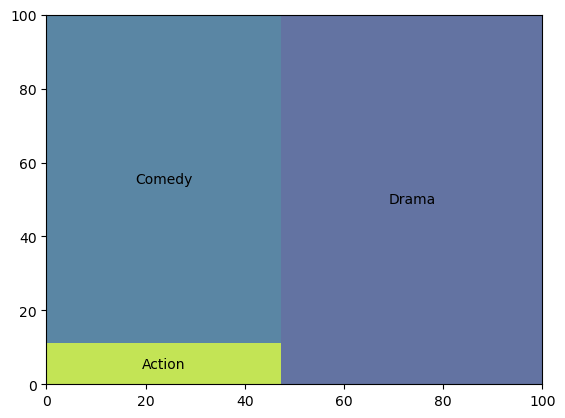

In [17]:
show_treemap(genre_count)